In [233]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.ndimage import gaussian_filter1d
from numba import njit
from scipy.stats import linregress

In [192]:
# Case a

##Engergy calculater
def Ha(Lattice, pool, J=1):
    spins = Lattice
    neighbours = np.roll(spins,-1)
    interactions = spins*neighbours
    return -J*np.sum(interactions)

def dHa(N, Lattice, pool, I, i, J=1):
    spins = Lattice
    l = (i-1)%N
    u = (i+1)%N
    return 2 * J * ( spins[l] + spins[u])*spins[i]

# Case b
##Same constants

def generate_neighbors(N):
    tries = 0
    while True:
        tries += 1
        pool = np.random.permutation(N)
        nxt  = np.roll(pool, -1)
        #ring neighbors are exactly distance 1 mod N in either direction
        diff = (pool - nxt) % N
        if not np.any((diff == 1) | (diff == N - 1)):
            return pool, tries

##Engergy calculater
def Hb(Lattice, pool, J=1):
    spins = Lattice
    pool_spins = spins[pool]
    neighbors1 = np.roll(spins,-1)
    neighbors2 = np.roll(pool_spins,-1)

    interactions1 = spins*neighbors1
    interactions2 = pool_spins*neighbors2
    return -J*(np.sum(interactions1) + np.sum(interactions2))

def dHb(N, Lattice, pool, I, i, J=1):
    spins = Lattice
    pool_spins = spins[pool]
    j = int(I[i])
    l = int((i-1)%N)
    u = int((i+1)%N)
    return 2 * J * (( spins[l] + spins[u] + pool_spins[(j-1)%N] + pool_spins[(j+1)%N])*spins[i])


def simulation(N, n, n0, T, style = "A"):
    if style == "A":
        H = Ha
        dH = dHa
        pool = []
        inv = np.empty(N, dtype=int)
    else:
        H = Hb
        dH = dHb
        pool, c = generate_neighbors(N)
        inv = np.empty(N, dtype=int)
        inv[pool] = np.arange(N)

    lat = np.random.choice([-1,1],N)
    
    s_list = np.zeros(int(n/N))
    m_list = np.zeros(int(n/N))
    H_list = np.zeros(int(n/N))
    M = np.sum(lat)
    E = H(lat, pool,J=1)
    m_list[0] = M
    H_list[0] = E
    for i in range(1,n):
        k = np.random.randint(N)
        r = np.random.uniform()
        dE = dH(N, lat, pool, inv, k, J=1)
        if dE <= 0:
            E += dE
            M += -2*lat[k]
            lat[k] = -lat[k]
            
        elif r < np.exp(-dE/T):
            E += dE
            M += -2*lat[k]
            lat[k] = -lat[k]
        if i%N == 0:
            u = int(i/N)
            H_list[u] = E
            m_list[u] = M
    m_mean = np.mean(m_list[int(n0/N):])
    m2 = np.mean(m_list[int(n0/N):]**2)
    m_abs = np.mean(np.abs(m_list[int(n0/N):]))/N
    chi = N * ( m2 - m_mean**2)/T
    H_final = np.mean(H_list[int(n0/N):])
    return m_abs, m2, H_final, chi


In [239]:
F = [5, 10, 20, 50, 100, 200, 500, 1000]
l = int(1e5)
T = np.concatenate([
    np.linspace(0.01, 1, 20, endpoint=False), 
    np.linspace(1, 3, 50, endpoint=False),
    np.linspace(3, 5, 20, endpoint=False),
    np.linspace(5, 15, 10)
])


m = 2

Sa_avg = np.zeros((m, len(F), len(T)))
Ha_avg = np.zeros((m, len(F), len(T)))
S2a_avg = np.zeros((m, len(F), len(T)))
chia_list = np.zeros((m, len(F), len(T)))

Sb_avg = np.zeros((m, len(F), len(T)))
Hb_avg = np.zeros((m, len(F), len(T)))
S2b_avg = np.zeros((m, len(F), len(T)))
chib_list = np.zeros((m, len(F), len(T)))
for _ in range(m):
    for d, f in enumerate(F):
        for i, t in enumerate(T):
            Sa_avg[_,d,i], S2a_avg[_,d,i], Ha_avg[_,d,i], chia_list[_,d,i] = simulation(f, l, int(l/4), t, style = "A")
            Sb_avg[_,d,i], S2b_avg[_,d,i], Hb_avg[_,d,i], chib_list[_,d,i] = simulation(f, l, int(l/4), t, style = "B")
        print(f)
    print(_/2, "way")

5
10
20
50
100
200
500
1000
0.0 way
5
10
20
50
100
200
500
1000
0.5 way


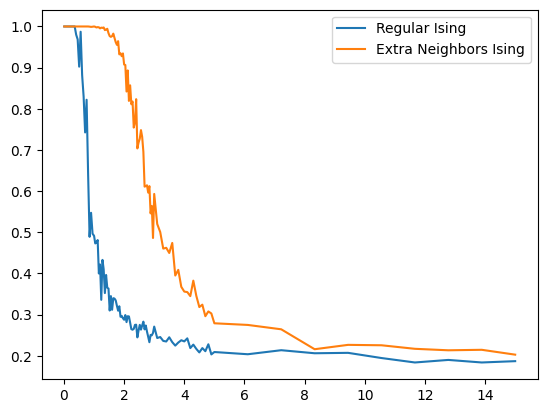

In [238]:
plt.plot(T, np.mean(Sa_avg[:,0,:],axis=0), label = "Regular Ising")
plt.plot(T, np.mean(Sb_avg[:,0,:],axis=0), label = "Extra Neighbors Ising")
plt.legend()
plt.show()

In [215]:
Sa_avg1 = Sa_avg[:,0,:]
Sb_avg1 = Sb_avg[:,0,:]
Ha_avg1 = Ha_avg[:,0,:]
Hb_avg1 = Hb_avg[:,0,:]
chib_list1 = chib_list[:,0,:]
chia_list1 = chia_list[:,0,:]

In [216]:
# collect into dict
arrays1 = {
    "Sa_avg1": Sa_avg1,
    "Sb_avg1": Sb_avg1,
    "Ha_avg1": Ha_avg1,
    "Hb_avg1": Hb_avg1,
    "chib_list1": chib_list1,
    "chia_list1": chia_list1,
}

# save to .npy
for name, arr in arrays1.items():
    np.save(f"{name}.npy", arr)
    print(f"Saved {name}.npy with shape {arr.shape}")

Saved Sa_avg1.npy with shape (2, 100)
Saved Sb_avg1.npy with shape (2, 100)
Saved Ha_avg1.npy with shape (2, 100)
Saved Hb_avg1.npy with shape (2, 100)
Saved chib_list1.npy with shape (2, 100)
Saved chia_list1.npy with shape (2, 100)


In [276]:
arrays = {
    "Sa_avg": Sa_avg,
    "Ha_avg": Ha_avg,
    "S2a_avg": S2a_avg,
    "chia_list": chia_list,
    "Sb_avg": Sb_avg,
    "Hb_avg": Hb_avg,
    "S2b_avg": S2b_avg,
    "chib_list": chib_list
}

# save each array
for name, arr in arrays.items():
    np.save(f"{name}.npy", arr)
    print(f"Saved {name}.npy")

Saved Sa_avg.npy
Saved Ha_avg.npy
Saved S2a_avg.npy
Saved chia_list.npy
Saved Sb_avg.npy
Saved Hb_avg.npy
Saved S2b_avg.npy
Saved chib_list.npy


In [224]:
# list of names
names = [
    "Sa_avg",
    "Ha_avg",
    "S2a_avg",
    "chia_list",
    "Sb_avg",
    "Hb_avg",
    "S2b_avg",
    "chib_list"
]

# load arrays into a dictionary
arrays_loaded = {}
for name in names:
    arrays_loaded[name] = np.load(f"{name}.npy")
    print(f"Loaded {name}.npy with shape {arrays_loaded[name].shape}")

Loaded Sa_avg.npy with shape (2, 5, 100)
Loaded Ha_avg.npy with shape (2, 5, 100)
Loaded S2a_avg.npy with shape (2, 5, 100)
Loaded chia_list.npy with shape (2, 5, 100)
Loaded Sb_avg.npy with shape (2, 5, 100)
Loaded Hb_avg.npy with shape (2, 5, 100)
Loaded S2b_avg.npy with shape (2, 5, 100)
Loaded chib_list.npy with shape (2, 5, 100)


In [241]:
F = np.array(F)

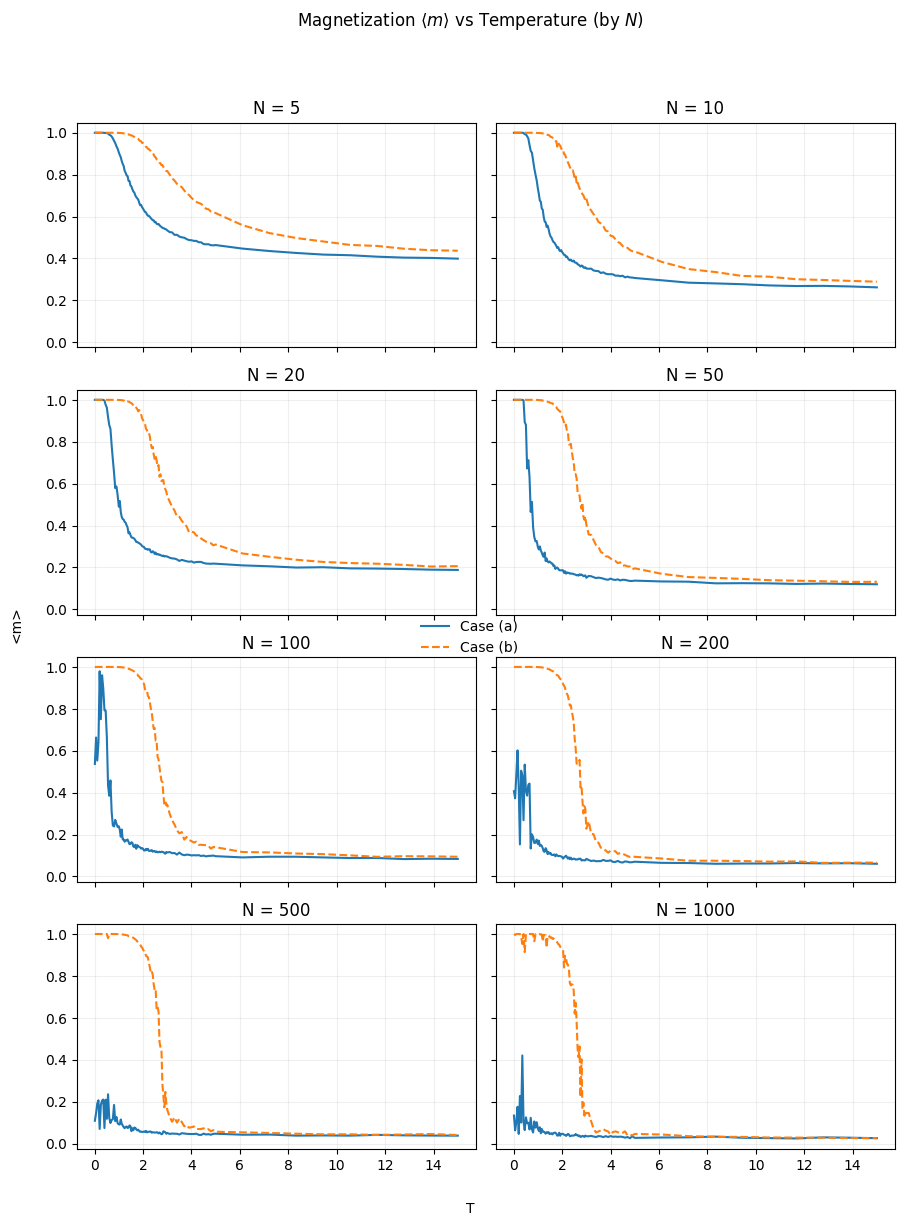

In [267]:
import numpy as np
import matplotlib.pyplot as plt
from math import ceil

n = len(F)
cols = 2              # 2 columns
rows = ceil(n / cols) # -> 4 rows if n = 8

fig, axes = plt.subplots(rows, cols, figsize=(5*cols, 3.2*rows), sharex=True, sharey=True)
axes = np.atleast_1d(axes).ravel()

for ax, (i, f) in zip(axes, enumerate(F)):
    curvea = np.mean(Sa_avg[:, i, :], axis=0)
    curveb = np.mean(Sb_avg[:, i, :], axis=0)
    ax.plot(T, curvea, linestyle='-',  label='(a)')
    ax.plot(T, curveb, linestyle='--', label='(b)')
    ax.set_title(f"N = {f}")
    ax.grid(True, alpha=0.2)

# hide any unused axes if rows*cols > n
for j in range(len(F), len(axes)):
    fig.delaxes(axes[j])

fig.suptitle(r"Magnetization $\langle m \rangle$ vs Temperature (by $N$)", y=0.98)
fig.text(0.5, 0.04, "T", ha='center')
fig.text(0.04, 0.5, r"<m>", va='center', rotation='vertical')

# one shared legend on the right
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, ['Case (a)', 'Case (b)'],
           loc='center', bbox_to_anchor=(0.5, 0.49), frameon=False)

plt.tight_layout(rect=[0.06, 0.06, 0.94, 0.95])
plt.show()


N =    5: T* (max |dcurveb|) = 2.84 |dcurveb| = 0.2145  (signed dcurveb = -0.2145)


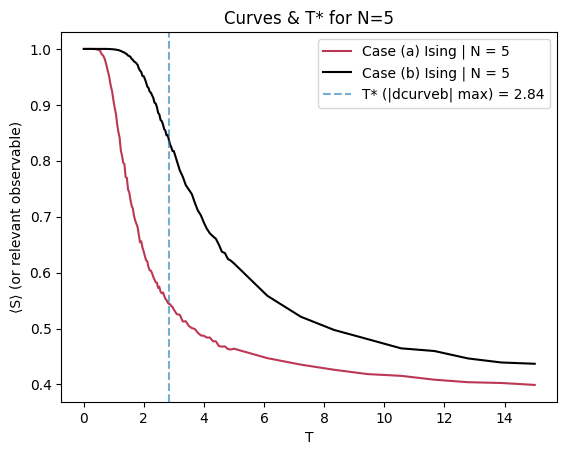

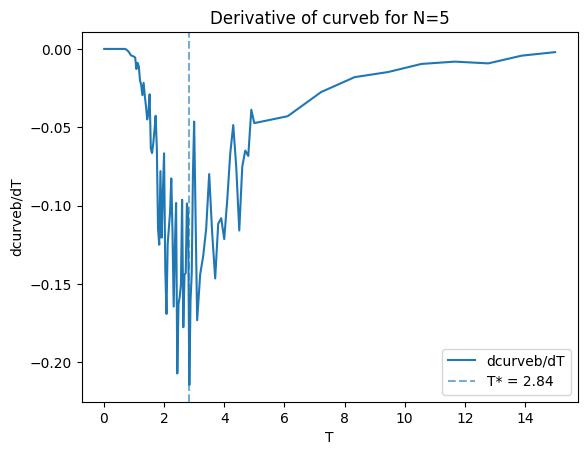

N =   10: T* (max |dcurveb|) = 2.48 |dcurveb| = 0.5325  (signed dcurveb = -0.5325)


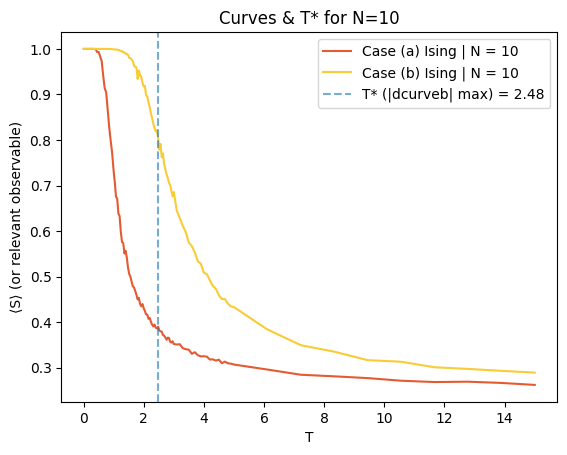

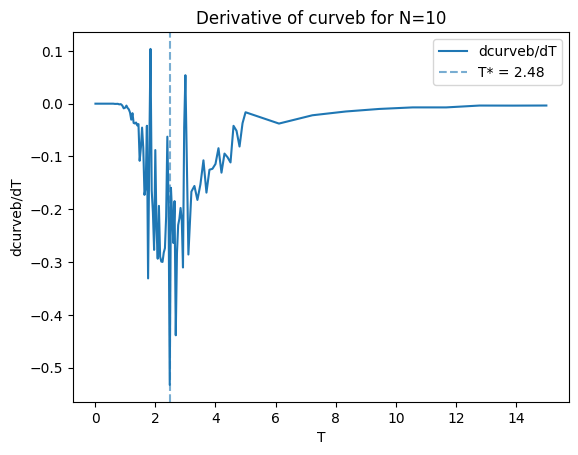

N =   20: T* (max |dcurveb|) = 2.44 |dcurveb| = 0.714  (signed dcurveb = -0.714)


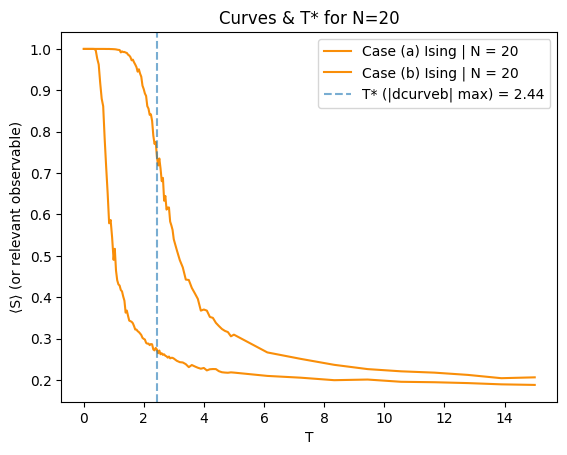

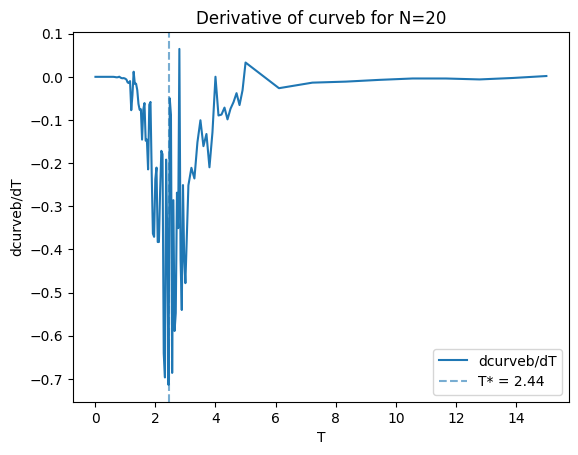

N =   50: T* (max |dcurveb|) = 2.6 |dcurveb| = 1.091  (signed dcurveb = -1.091)


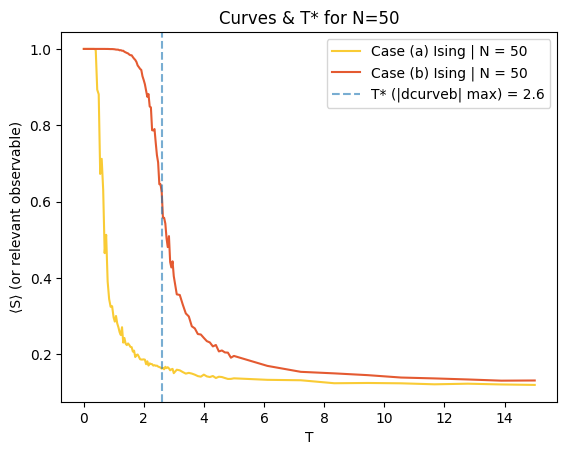

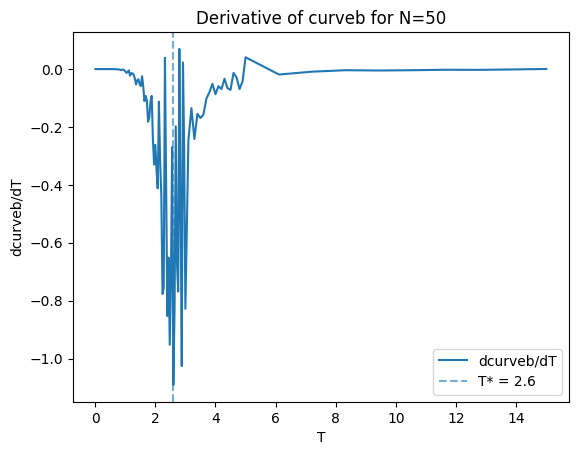

N =  100: T* (max |dcurveb|) = 2.84 |dcurveb| = 1.28617  (signed dcurveb = -1.28617)


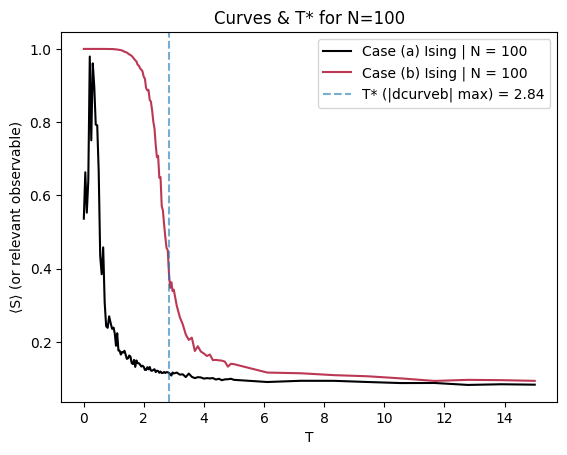

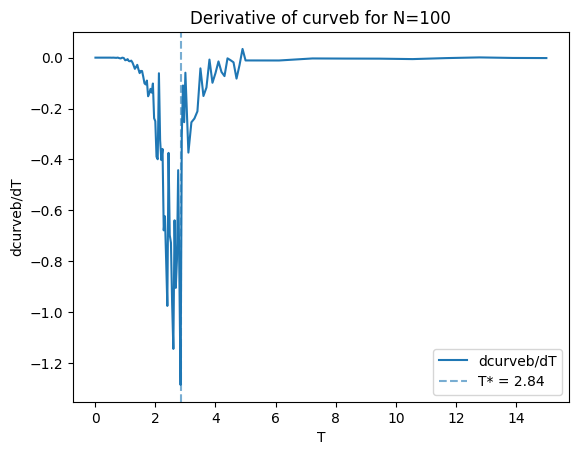

N =  200: T* (max |dcurveb|) = 2.84 |dcurveb| = 1.671  (signed dcurveb = -1.671)


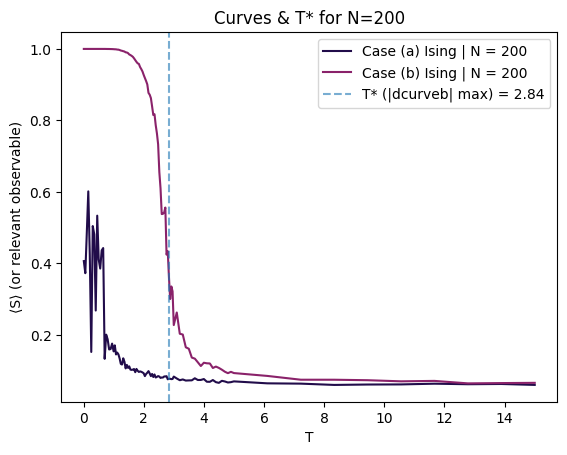

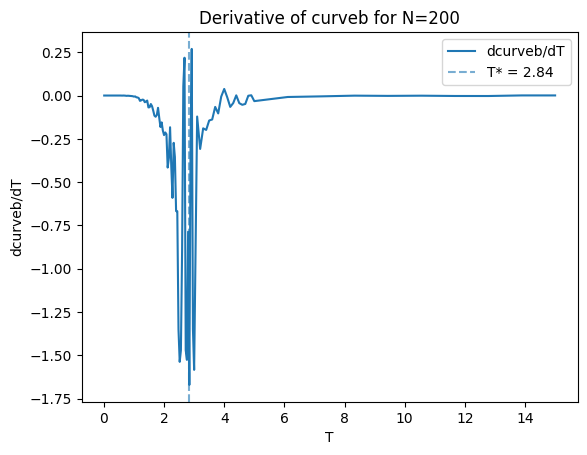

N =  500: T* (max |dcurveb|) = 2.8 |dcurveb| = 2.76433  (signed dcurveb = -2.76433)


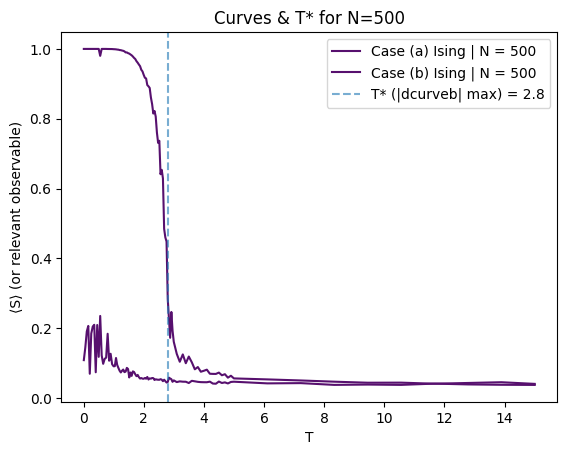

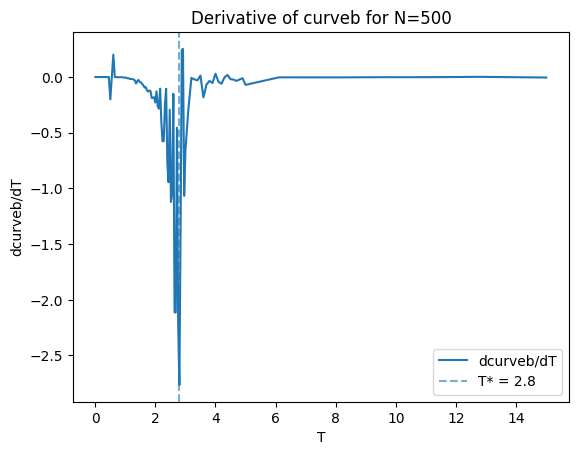

N = 1000: T* (max |dcurveb|) = 2.6 |dcurveb| = 2.76617  (signed dcurveb = -2.76617)


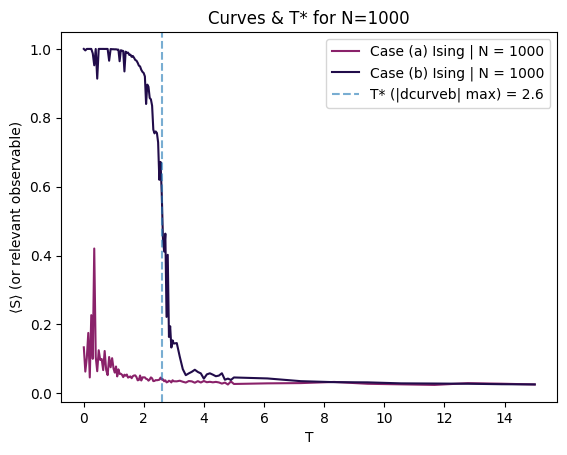

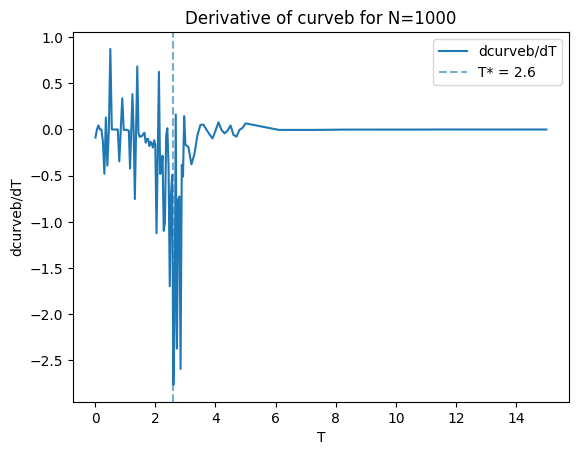


(Separating rise vs. drop)
N =    5:  steepest rise at T = 0.2575 (d=1.77636e-15); steepest drop at T = 2.84 (d=-0.2145)
N =   10:  steepest rise at T = 1.84 (d=0.103667); steepest drop at T = 2.48 (d=-0.5325)
N =   20:  steepest rise at T = 2.8 (d=0.0646667); steepest drop at T = 2.44 (d=-0.714)
N =   50:  steepest rise at T = 2.8 (d=0.0696667); steepest drop at T = 2.6 (d=-1.091)
N =  100:  steepest rise at T = 4.9 (d=0.0342667); steepest drop at T = 2.84 (d=-1.28617)
N =  200:  steepest rise at T = 2.92 (d=0.269167); steepest drop at T = 2.84 (d=-1.671)
N =  500:  steepest rise at T = 2.92 (d=0.2525); steepest drop at T = 2.8 (d=-2.76433)
N = 1000:  steepest rise at T = 0.505 (d=0.872054); steepest drop at T = 2.6 (d=-2.76617)
Fit: T_c(1/F) = 0.028060 * (1/F) + 2.678639
Extrapolated T_c at F -> ∞: 2.678639


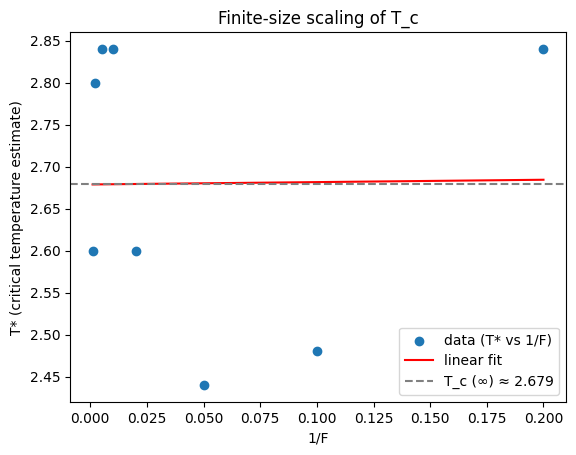

In [275]:
# Compute dcurveb and find the T where |dcurveb/dT| is largest for each F
T = np.asarray(T)
t_star_b = []           # T* per F where |dcurveb| is maximal
dcurveb_peaks = []      # corresponding derivative values (signed)

for i, f in enumerate(F):
    curvea = np.mean(Sa_avg[:, i, :], axis=0)
    curveb = np.mean(Sb_avg[:, i, :], axis=0)

    # numerical derivative w.r.t. T; handles nonuniform T as well
    dcurveb = np.gradient(curveb, T)

    # index of largest absolute change (steepest slope magnitude)
    k = int(np.nanargmax(np.abs(dcurveb)))
    T_star = T[k]
    d_at_star = dcurveb[k]

    t_star_b.append(T_star)
    dcurveb_peaks.append(d_at_star)

    print(f"N = {f:>4}: T* (max |dcurveb|) = {T_star:.6g} "
          f"|dcurveb| = {abs(d_at_star):.6g}  (signed dcurveb = {d_at_star:.6g})")

    # --- (optional) plotting ---
    plt.figure()
    plt.plot(T, curvea, color=colors[int((i+4) % len(F))], label=f"Case (a) Ising | N = {f}")
    plt.plot(T, curveb, color=colors[-i], label=f"Case (b) Ising | N = {f}")
    # mark the T* from curveb
    plt.axvline(T_star, linestyle="--", alpha=0.6, label=f"T* (|dcurveb| max) = {T_star:.3g}")
    plt.legend()
    plt.xlabel("T")
    plt.ylabel("⟨S⟩ (or relevant observable)")
    plt.title(f"Curves & T* for N={f}")
    plt.show()

    # If you want to see the derivative itself:
    plt.figure()
    plt.plot(T, dcurveb, label="dcurveb/dT")
    plt.axvline(T_star, linestyle="--", alpha=0.6, label=f"T* = {T_star:.3g}")
    plt.xlabel("T")
    plt.ylabel("dcurveb/dT")
    plt.title(f"Derivative of curveb for N={f}")
    plt.legend()
    plt.show()

# If you also want steepest rise vs steepest drop separately:
print("\n(Separating rise vs. drop)")
for i, f in enumerate(F):
    curveb = np.mean(Sb_avg[:, i, :], axis=0)
    dcurveb = np.gradient(curveb, T)
    k_up = int(np.nanargmax(dcurveb))         # max positive slope
    k_dn = int(np.nanargmin(dcurveb))         # most negative slope
    print(f"N = {f:>4}:  steepest rise at T = {T[k_up]:.6g} (d={dcurveb[k_up]:.6g}); "
          f"steepest drop at T = {T[k_dn]:.6g} (d={dcurveb[k_dn]:.6g})")
import numpy as np
from sklearn.linear_model import LinearRegression

# Convert to arrays
F = np.asarray(F)
invF = 1.0 / F
t_star_b = np.asarray(t_star_b)

# Reshape for sklearn
X = invF.reshape(-1, 1)
y = t_star_b

# Linear regression T_c = a*(1/F) + b
linreg = LinearRegression().fit(X, y)
a = linreg.coef_[0]
b = linreg.intercept_  # this is the extrapolated T_c at 1/F -> 0

print(f"Fit: T_c(1/F) = {a:.6f} * (1/F) + {b:.6f}")
print(f"Extrapolated T_c at F -> ∞: {b:.6f}")

# --- plotting ---
plt.figure()
plt.scatter(invF, t_star_b, label="data (T* vs 1/F)")
plt.plot(invF, linreg.predict(X), color="red", label="linear fit")
plt.axhline(b, color="gray", linestyle="--", label=f"T_c (∞) ≈ {b:.3f}")
plt.xlabel("1/F")
plt.ylabel("T* (critical temperature estimate)")
plt.legend()
plt.title("Finite-size scaling of T_c")
plt.show()


2.56


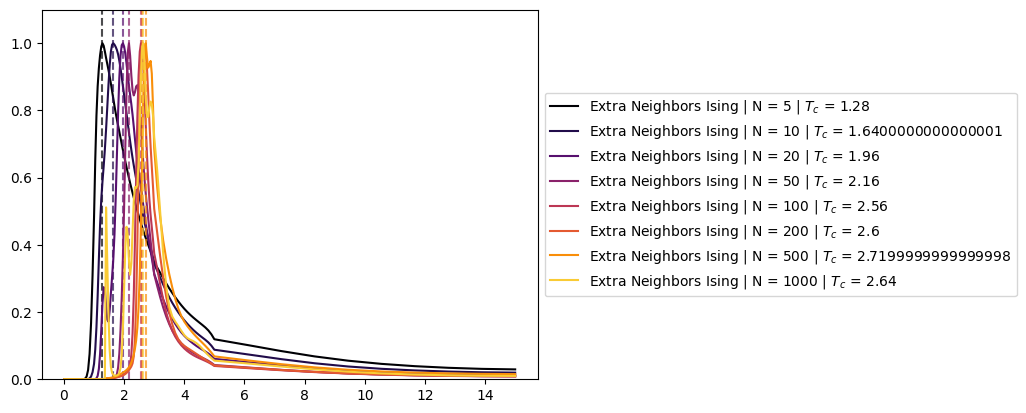

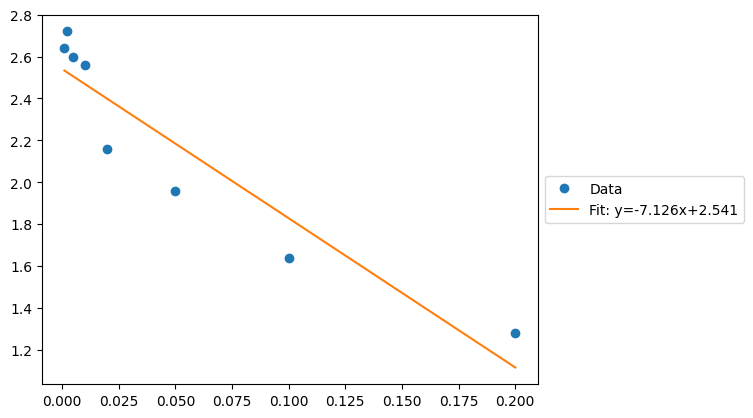

'\nplt.plot(T[:10], (F/T * ( np.mean(np.mean(ma_list[0]**2, axis= 1), axis=0) - np.mean(np.mean(ma_list[0], axis= 1),axis=0)**2 ))[:10], label = "Regular Ising")\nplt.plot(T[:10], (F/T * ( np.mean(np.mean(mb_list[0]**2, axis= 1), axis=0) - np.mean(np.mean(mb_list[0], axis= 1),axis=0)**2 ))[:10], label = "Extra Neighbors Ising")\nplt.legend()\nplt.show()\n'

In [248]:
#plt.plot(T, np.mean(Sa_avg[:,i,:],axis=0), label = "Regular Ising")
#plt.plot(T, np.mean(Sb_avg[:,i,:],axis=0), label = "Extra Neighbors Ising")
#plt.legend()
#plt.show()
#plt.plot(T, np.mean(Ha_avg[:,i,:],axis=0)/f, label = "Regular Ising")
#plt.plot(T, np.mean(Hb_avg[:,i,:],axis=0)/f, label = "Extra Neighbors Ising")
#plt.legend()
#plt.show()
#plt.plot(T, np.mean(chia_list[:,i,:],axis=0), label = f"Regular Ising | N = {f}")
cmap = plt.cm.inferno  # heat-style colormap
colors = [cmap(i/len(F)) for i in range(len(F))]
Tc_list = np.zeros(len(F))
for i, f in enumerate(F):
    if i < 4:
        curve = gaussian_filter1d(np.mean(chib_list[:, i, :], axis=0), sigma=2)
    else:
        curve = gaussian_filter1d(np.mean(chib_list[:, i, :], axis=0), sigma=2)
        curve[:30] = np.zeros(30)
    if i != 4:
        T_c = T[np.argmax(curve)]
    else:
        T_c = T[int(np.argmax(curve[30:]) + 30)]
        print(T_c)

    plt.axvline(T_c, color=colors[i], linestyle='--', alpha=0.7)
    plt.plot(T, curve, color=colors[i], label=f"Extra Neighbors Ising | N = {f} | $T_c$ = {T_c}")
    Tc_list[i] = T_c
plt.legend(loc='center left', bbox_to_anchor=(1, 0.5))
plt.ylim(0,1e0+0.1)
plt.show()
x = 1/F
y = Tc_list

slope, intercept, r_value, p_value, std_err = linregress(x, y)

# regression line
x_fit = np.linspace(min(x), max(x), 100)
y_fit = slope * x_fit + intercept

plt.plot(x, y, 'o', label='Data')
plt.plot(x_fit, y_fit, '-', label=f'Fit: y={slope:.3f}x+{intercept:.3f}')
plt.legend(loc='center left', bbox_to_anchor=(1, 0.5))
plt.show()

'''
plt.plot(T[:10], (F/T * ( np.mean(np.mean(ma_list[0]**2, axis= 1), axis=0) - np.mean(np.mean(ma_list[0], axis= 1),axis=0)**2 ))[:10], label = "Regular Ising")
plt.plot(T[:10], (F/T * ( np.mean(np.mean(mb_list[0]**2, axis= 1), axis=0) - np.mean(np.mean(mb_list[0], axis= 1),axis=0)**2 ))[:10], label = "Extra Neighbors Ising")
plt.legend()
plt.show()
'''

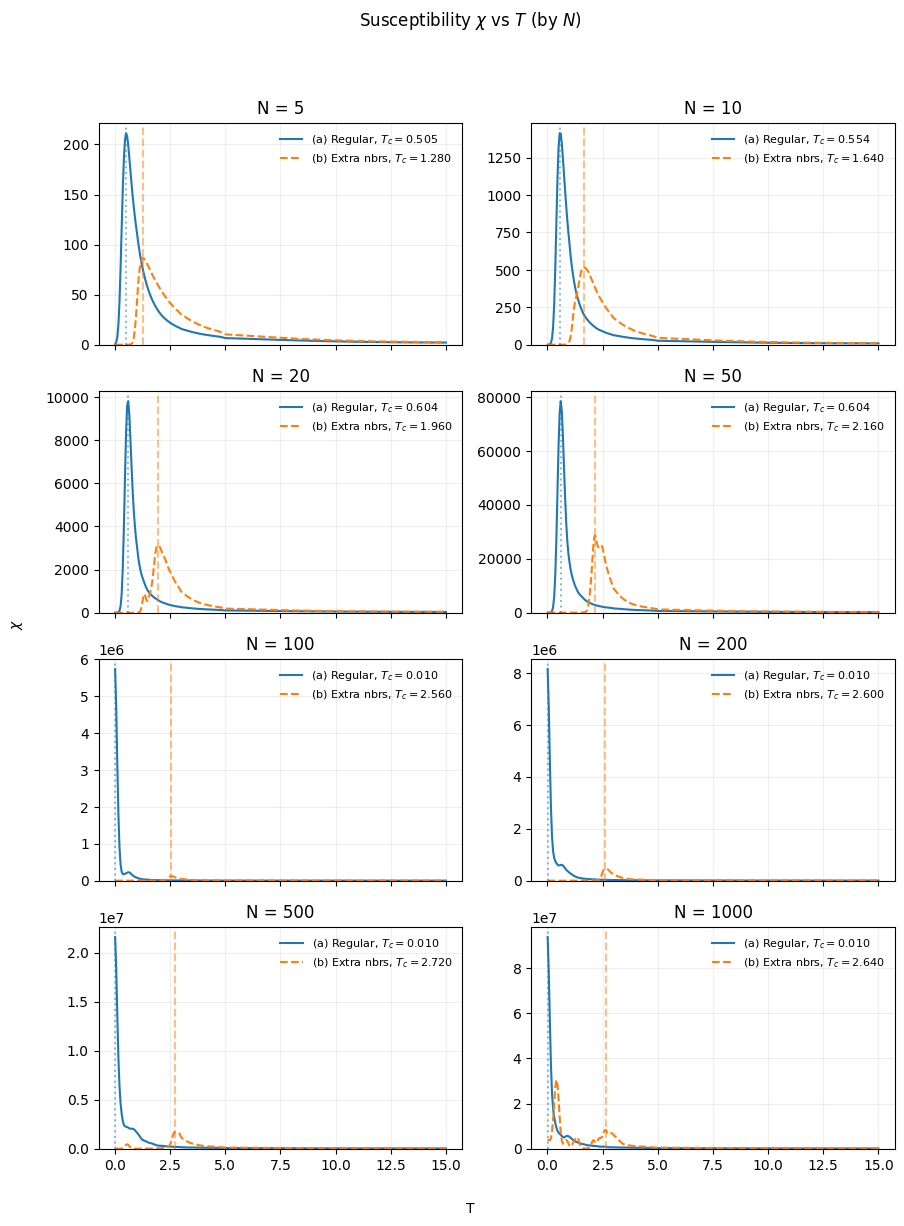

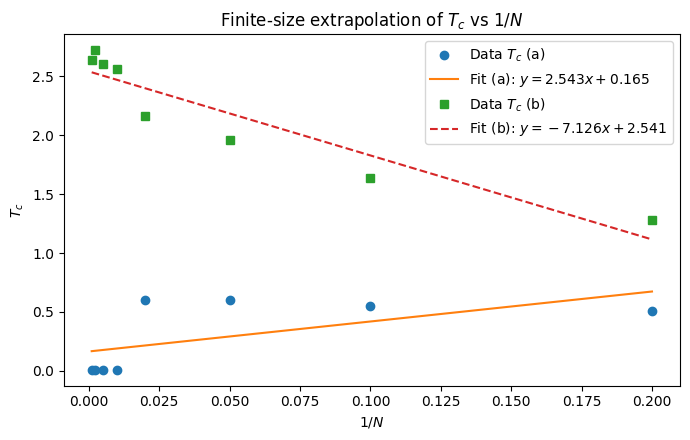

Extrapolated T_c (a) as N→∞ ≈ 0.1651  (R²=0.353)
Extrapolated T_c (b) as N→∞ ≈ 2.5406  (R²=0.881)


In [273]:
import numpy as np
import matplotlib.pyplot as plt
from math import ceil
from scipy.ndimage import gaussian_filter1d
from scipy.stats import linregress

SMOOTH_SIGMA = 2
IGNORE_FIRST_IDX = 30

n = len(F)
cols = 2
rows = ceil(n / cols)

fig, axes = plt.subplots(rows, cols, figsize=(5*cols, 3.2*rows), sharex=True)  
axes = np.atleast_1d(axes).ravel()

Tc_a = np.zeros(n)
Tc_b = np.zeros(n)

for ax, (i, f) in zip(axes, enumerate(F)):
    chi_a = np.mean(chia_list[:, i, :], axis=0)
    chi_b = np.mean(chib_list[:, i, :], axis=0)

    chi_a_s = gaussian_filter1d(chi_a, sigma=SMOOTH_SIGMA)
    chi_b_s = gaussian_filter1d(chi_b, sigma=SMOOTH_SIGMA)

    # --- Locate Tc ---
    idx_a = np.argmax(chi_a_s)  # case (a): never ignore
    Tc_a[i] = T[idx_a]

    if f > 50:  # case (b): ignore first 30 points if N>50
        idx_b = np.argmax(chi_b_s[IGNORE_FIRST_IDX:]) + IGNORE_FIRST_IDX
    else:
        idx_b = np.argmax(chi_b_s)
    Tc_b[i] = T[idx_b]

    # --- Plot curves ---
    ax.plot(T, chi_a_s, '-',  label=f'(a) Regular, $T_c={Tc_a[i]:.3f}$')
    ax.plot(T, chi_b_s, '--', label=f'(b) Extra nbrs, $T_c={Tc_b[i]:.3f}$')

    # vertical lines
    ax.axvline(Tc_a[i], linestyle=':',  alpha=0.5, color='C0')
    ax.axvline(Tc_b[i], linestyle='--', alpha=0.5, color='C1')

    # per-panel ylim
    ymax = np.nanmax([np.nanmax(chi_a_s), np.nanmax(chi_b_s)])
    ax.set_ylim(0, ymax * 1.05 if ymax > 0 else 1)

    ax.set_title(f"N = {f}")
    ax.grid(True, alpha=0.2)

    # --- Local legend for this subplot ---
    ax.legend(loc='best', fontsize=8, frameon=False)

# Hide unused axes
for j in range(len(F), len(axes)):
    fig.delaxes(axes[j])

fig.suptitle(r"Susceptibility $\chi$ vs $T$ (by $N$)", y=0.98)
fig.text(0.5, 0.04, "T", ha='center')
fig.text(0.04, 0.5, r"$\chi$", va='center', rotation='vertical')

plt.tight_layout(rect=[0.06, 0.06, 0.94, 0.95])
plt.show()


# ---- Regression (unchanged) ----
x = 1 / np.array(F, dtype=float)
slope_a, intercept_a, r_a, _, _ = linregress(x, Tc_a)
slope_b, intercept_b, r_b, _, _ = linregress(x, Tc_b)

x_fit = np.linspace(x.min(), x.max(), 200)
y_fit_a = slope_a * x_fit + intercept_a
y_fit_b = slope_b * x_fit + intercept_b

plt.figure(figsize=(7,4.5))
plt.plot(x, Tc_a, 'o', label=r'Data $T_c$ (a)')
plt.plot(x_fit, y_fit_a, '-', label=fr'Fit (a): $y={slope_a:.3f}x+{intercept_a:.3f}$')
plt.plot(x, Tc_b, 's', label=r'Data $T_c$ (b)')
plt.plot(x_fit, y_fit_b, '--', label=fr'Fit (b): $y={slope_b:.3f}x+{intercept_b:.3f}$')
plt.xlabel(r'$1/N$')
plt.ylabel(r'$T_c$')
plt.title(r'Finite-size extrapolation of $T_c$ vs $1/N$')
plt.legend(loc='best')
plt.tight_layout()
plt.show()

print(f"Extrapolated T_c (a) as N→∞ ≈ {intercept_a:.4f}  (R²={r_a**2:.3f})")
print(f"Extrapolated T_c (b) as N→∞ ≈ {intercept_b:.4f}  (R²={r_b**2:.3f})")


C:\Users\lucq0\AppData\Local\Temp\ipykernel_22372\1124484642.py:2: RuntimeWarning: divide by zero encountered in divide
  return((1-2/x)**x)
C:\Users\lucq0\AppData\Local\Temp\ipykernel_22372\1124484642.py:2: RuntimeWarning: invalid value encountered in power
  return((1-2/x)**x)


(0.1343352832366127, 0.1363352832366127)

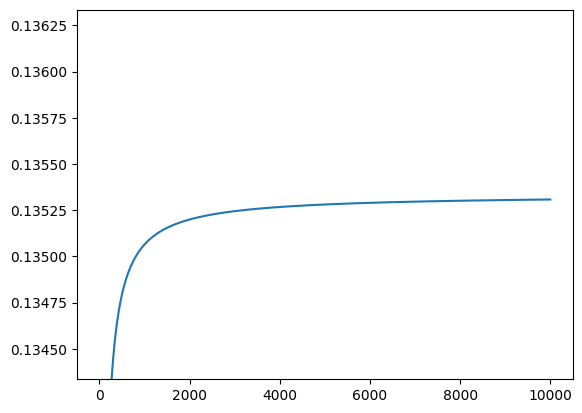

In [ ]:
#Filler earlier functions
def remove_one_occurrence(pool, val):
    pos = np.where(pool == val)[0][0]  # first occurrence
    return np.delete(pool, pos)

def generate_neighbors(N, tries=10):

    while True:
        # initialize
        neighbors = [{(i - 1) % N, (i + 1) % N} for i in range(N)]
        # pool of candidates for neighbors
        pool = np.arange(N)

        attempt_failed = False

        for i in range(N):
            #What we must not pick
            forbidden = neighbors[i] | {i}

            need = 1

            while need > 0:
                #currently allowed values from the pool
                allowed_mask = ~np.isin(pool, list(forbidden))
                allowed_vals = np.unique(pool[allowed_mask])

                if allowed_vals.size < 1:
                    #dead end for this attempt so restart whole run
                    attempt_failed = True
                    break

                # pick one new neighbor (change size=need and remove multiple occurrences if you want batch)
                choice = rng.choice(allowed_vals, size=1, replace=False)[0]

                # update neighbors (i <- choice)
                neighbors[i].add(int(choice))

                neighbors[int(choice)].add(i)

                # update constraints so we dont pick the same again
                forbidden.add(int(choice))
                #update pool
                pool = remove_one_occurrence(pool, choice)

                need -= 1

            if attempt_failed:
                break  # break the for i in range(N) loop

        if not attempt_failed:
            # success!
            return neighbors, pool

        # otherwise loop to next attempt

    # if we get here, all attempts failed
    print(neighbors)
    print(pool)
    raise RuntimeError(f"Failed to construct neighbors after {tries} attempts.")